# 第一章：複雜動力學第一定律 - PyTorch 實作
## The First Law of Complexodynamics

**原論文：Scott Aaronson (2011)**  
**連結：https://scottaaronson.blog/?p=762**

---

### 本章重點

1. **熵永遠增加，但複雜度先升後降**
2. 使用細胞自動機（Rule 30）展示複雜性從簡單規則中湧現
3. 使用二維擴散模擬（咖啡自動機）展示不可逆混合過程

In [1]:
# 跨平台中文字型設定（支援 Colab、VSCode、Antigravity 等本地環境）
import subprocess
import os
import shutil
import platform

system = platform.system()

# 必須在 import matplotlib 之前清除快取
cache_dir = os.path.expanduser('~/.matplotlib')
if os.path.exists(cache_dir):
    for f in os.listdir(cache_dir):
        if f.startswith('fontlist'):
            try:
                os.remove(os.path.join(cache_dir, f))
            except:
                pass

cache_dir2 = os.path.expanduser('~/.cache/matplotlib')
if os.path.exists(cache_dir2):
    shutil.rmtree(cache_dir2, ignore_errors=True)

# Linux/Colab 環境安裝中文字型
if system == 'Linux' or 'COLAB_GPU' in os.environ or os.path.exists('/content'):
    try:
        result = subprocess.run(['fc-list', ':lang=zh'], capture_output=True, text=True)
        if 'Noto Sans CJK' not in result.stdout:
            print("正在安裝中文字型...")
            subprocess.run(['apt-get', 'update', '-qq'], capture_output=True)
            subprocess.run(['apt-get', 'install', '-qq', '-y', 'fonts-noto-cjk'], capture_output=True)
            print("中文字型安裝完成，請重新啟動 kernel")
    except:
        pass

print(f"✓ {system} 環境")

正在安裝中文字型...
中文字型安裝完成，請重新啟動 kernel
✓ Linux 環境


In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 重建字型快取並設定中文字型
from matplotlib.font_manager import fontManager
fontManager.__init__()

chinese_fonts = [
    'Heiti TC', 'PingFang TC', 'Noto Sans CJK TC',
    'Heiti SC', 'PingFang SC', 'Noto Sans CJK SC', 
    'Microsoft JhengHei', 'Microsoft YaHei',
    'SimHei', 'WenQuanYi Micro Hei', 'Arial Unicode MS',
]

available_fonts = set(f.name for f in fontManager.ttflist)
selected_font = None
for font in chinese_fonts:
    if font in available_fonts:
        selected_font = font
        break

if selected_font:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [selected_font] + chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print(f"✓ 使用中文字型: {selected_font}")
else:
    plt.rcParams['font.sans-serif'] = chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print("⚠ 使用預設字型列表")

import matplotlib
from typing import Callable, Tuple
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# 設定隨機種子以確保可重現性
torch.manual_seed(42)

# 跨平台中文字型設定
# 字型優先順序：涵蓋 Mac, Windows, Linux, Colab 常見中文字型
chinese_fonts = [
    'Noto Sans CJK TC',      # Linux/Colab/Mac(安裝後)
    'Noto Sans CJK SC',      # Linux/Colab/Mac(安裝後) 簡體
    'Heiti TC',              # Mac 內建 繁體
    'Heiti SC',              # Mac 內建 簡體
    'PingFang TC',           # Mac 內建 繁體
    'PingFang SC',           # Mac 內建 簡體
    'Microsoft JhengHei',    # Windows 微軟正黑體 繁體
    'Microsoft YaHei',       # Windows 微軟雅黑 簡體
    'SimHei',                # Windows 黑體
    'WenQuanYi Micro Hei',   # Linux 文泉驛微米黑
    'Droid Sans Fallback',   # Android/舊版 Linux
    'Arial Unicode MS',      # 跨平台 Unicode 字型
    'DejaVu Sans',           # 後備字型
]

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = chinese_fonts
plt.rcParams['axes.unicode_minus'] = False  # 正確顯示負號
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# 驗證字型設定
def verify_chinese_font():
    """驗證中文字型是否正確載入"""
    from matplotlib.font_manager import FontManager
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in chinese_fonts:
        if font in available:
            print(f"✓ 使用中文字型: {font}")
            return font
    print("⚠ 警告：未找到中文字型，中文可能無法正確顯示")
    return None

print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")
verify_chinese_font()

⚠ 使用預設字型列表
PyTorch 版本: 2.9.0+cu126
CUDA 可用: True
✓ 使用中文字型: DejaVu Sans


'DejaVu Sans'

---

## 1. 一維細胞自動機 (1D Cellular Automaton)

### 1.1 什麼是細胞自動機？

細胞自動機是一種離散計算模型：
- **空間**：一排格子（細胞），每個細胞有一個狀態（0 或 1）
- **時間**：離散的時間步
- **規則**：每個細胞根據自己和鄰居的狀態，更新到下一個狀態

### 1.2 Rule 30

Stephen Wolfram 發現的著名規則，能從極簡單的初始狀態產生複雜模式。

**規則表：**

| 左 | 中 | 右 | → | 新狀態 |
|---|---|---|---|---|
| 1 | 1 | 1 | → | 0 |
| 1 | 1 | 0 | → | 0 |
| 1 | 0 | 1 | → | 0 |
| 1 | 0 | 0 | → | 1 |
| 0 | 1 | 1 | → | 1 |
| 0 | 1 | 0 | → | 1 |
| 0 | 0 | 1 | → | 1 |
| 0 | 0 | 0 | → | 0 |

二進位：`00011110` = 30

**數學表示：**

$$f(l, c, r) = l \oplus (c \lor r)$$

其中 $\oplus$ 是 XOR，$\lor$ 是 OR。

In [3]:
def rule_30(left: torch.Tensor, center: torch.Tensor, right: torch.Tensor) -> torch.Tensor:
    """
    Rule 30: 產生複雜、混沌的模式
    
    數學公式: f(l, c, r) = l XOR (c OR r)
    
    這個簡單的規則卻能從單一細胞產生看似隨機的複雜模式，
    展示了複雜性可以從簡單規則中湧現。
    
    Args:
        left: 左鄰居狀態
        center: 自己的狀態
        right: 右鄰居狀態
    
    Returns:
        新狀態
    """
    return (left ^ (center | right)).long()


# 驗證 Rule 30
print("驗證 Rule 30 規則表：")
print("左 中 右 → 新狀態")
for l in [1, 0]:
    for c in [1, 0]:
        for r in [1, 0]:
            result = rule_30(
                torch.tensor(l), 
                torch.tensor(c), 
                torch.tensor(r)
            )
            print(f" {l}  {c}  {r}  →   {result.item()}")

驗證 Rule 30 規則表：
左 中 右 → 新狀態
 1  1  1  →   0
 1  1  0  →   0
 1  0  1  →   0
 1  0  0  →   1
 0  1  1  →   1
 0  1  0  →   1
 0  0  1  →   1
 0  0  0  →   0


### 1.3 細胞自動機演化函數

使用週期性邊界條件（最左邊的鄰居是最右邊的細胞），模擬環形排列。

**`torch.roll` 的妙用：**
```python
x = torch.tensor([1, 2, 3, 4, 5])
torch.roll(x, 1)   # tensor([5, 1, 2, 3, 4]) - 右移
torch.roll(x, -1)  # tensor([2, 3, 4, 5, 1]) - 左移
```

In [4]:
def evolve_ca(initial_state: torch.Tensor,
              steps: int,
              rule_func: Callable) -> torch.Tensor:
    """
    演化細胞自動機
    
    Args:
        initial_state: 初始狀態 (1D tensor)
        steps: 演化步數
        rule_func: 規則函數，接受 (left, center, right) 返回新狀態
    
    Returns:
        演化歷史 (steps x size tensor)
    """
    size = len(initial_state)
    history = torch.zeros((steps, size), dtype=torch.long)
    history[0] = initial_state
    
    for t in range(1, steps):
        # 使用 roll 實現週期性邊界條件
        left = torch.roll(history[t-1], 1)    # 左鄰居
        center = history[t-1]                  # 自己
        right = torch.roll(history[t-1], -1)   # 右鄰居
        
        history[t] = rule_func(left, center, right)
    
    return history


# 展示 torch.roll 的效果
print("torch.roll 示範：")
x = torch.tensor([1, 2, 3, 4, 5])
print(f"原始:      {x.tolist()}")
print(f"roll(x,1): {torch.roll(x, 1).tolist()}  ← 右移，5 繞到開頭")
print(f"roll(x,-1):{torch.roll(x, -1).tolist()}  ← 左移，1 繞到結尾")

torch.roll 示範：
原始:      [1, 2, 3, 4, 5]
roll(x,1): [5, 1, 2, 3, 4]  ← 右移，5 繞到開頭
roll(x,-1):[2, 3, 4, 5, 1]  ← 左移，1 繞到結尾


### 1.4 運行 Rule 30 細胞自動機

In [5]:
# 建立簡單初始狀態：中間一個細胞為 1，其餘為 0
size = 100
initial = torch.zeros(size, dtype=torch.long)
initial[size // 2] = 1

print(f"初始狀態: 大小 {size}, 中間一個細胞為 1")
print(f"初始狀態 (中間 20 個細胞): ...{initial[40:60].tolist()}...")

# 演化 100 步
steps = 100
evolution = evolve_ca(initial, steps, rule_30)

print(f"\n演化完成: {steps} 步")
print(f"最終狀態 1 的數量: {evolution[-1].sum().item()}/{size}")

初始狀態: 大小 100, 中間一個細胞為 1
初始狀態 (中間 20 個細胞): ...[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]...

演化完成: 100 步
最終狀態 1 的數量: 42/100


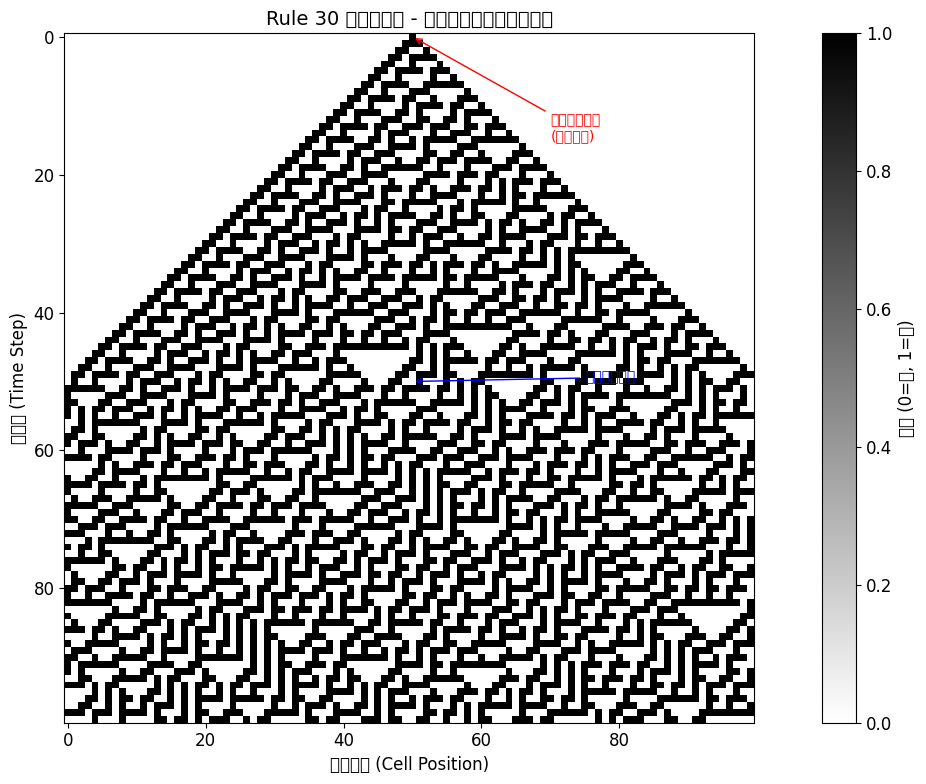


觀察：從極簡單的初始狀態（一個點），Rule 30 產生了看似隨機的複雜模式！
這展示了複雜動力學第一定律：複雜性可以從簡單規則中湧現。


In [6]:
# 視覺化演化過程
plt.figure(figsize=(14, 8))
plt.imshow(evolution.numpy(), cmap='binary', interpolation='nearest')
plt.title('Rule 30 細胞自動機 - 從單一細胞產生複雜模式', fontsize=14)
plt.xlabel('細胞位置 (Cell Position)')
plt.ylabel('時間步 (Time Step)')
plt.colorbar(label='狀態 (0=白, 1=黑)')

# 標註關鍵觀察
plt.annotate('簡單初始狀態\n(單一細胞)', xy=(50, 0), xytext=(70, 15),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='red'),
             color='red')
plt.annotate('複雜模式湧現', xy=(50, 50), xytext=(75, 50),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='blue'),
             color='blue')

plt.tight_layout()
plt.show()

print("\n觀察：從極簡單的初始狀態（一個點），Rule 30 產生了看似隨機的複雜模式！")
print("這展示了複雜動力學第一定律：複雜性可以從簡單規則中湧現。")

---

## 2. 熵與複雜度測量

### 2.1 Shannon 熵

**定義：**
$$H = -\sum_{i=1}^{n} p_i \log_2 p_i$$

**直觀理解：**
- 全 0 或全 1：H = 0（完全確定）
- 一半 0 一半 1：H = 1 bit（最大不確定性）

In [7]:
def measure_entropy(state: torch.Tensor) -> float:
    """
    計算狀態的 Shannon 熵
    
    H = -Σ p_i log₂(p_i)
    
    Args:
        state: 狀態向量
    
    Returns:
        熵值 (bits)
    """
    # 統計每個值出現的次數
    unique, counts = torch.unique(state, return_counts=True)
    
    # 計算機率
    probs = counts.float() / len(state)
    
    # 計算熵（加入小量避免 log(0)）
    entropy = -torch.sum(probs * torch.log2(probs + 1e-10))
    
    return entropy.item()


# 測試熵計算
print("Shannon 熵測試：")
print("=" * 50)

# 全 0
state_all_zeros = torch.zeros(100, dtype=torch.long)
print(f"全 0 序列:    H = {measure_entropy(state_all_zeros):.4f} bits")

# 全 1
state_all_ones = torch.ones(100, dtype=torch.long)
print(f"全 1 序列:    H = {measure_entropy(state_all_ones):.4f} bits")

# 一半 0 一半 1（交替）
state_alternating = torch.tensor([0, 1] * 50)
print(f"交替 01 序列: H = {measure_entropy(state_alternating):.4f} bits")

# 隨機
state_random = torch.randint(0, 2, (100,))
print(f"隨機序列:     H = {measure_entropy(state_random):.4f} bits")

print("\n理論最大熵（二元）: 1.0 bits")

Shannon 熵測試：
全 0 序列:    H = -0.0000 bits
全 1 序列:    H = -0.0000 bits
交替 01 序列: H = 1.0000 bits
隨機序列:     H = 0.9896 bits

理論最大熵（二元）: 1.0 bits


### 2.2 空間複雜度

使用「相鄰元素轉換次數」作為複雜度的代理指標。

**直觀理解：**
- 全 0 或全 1：轉換次數 = 0（最簡單）
- 01010101...：轉換次數 = n-1（最多轉換，但有規律）
- 複雜模式：轉換次數適中，但模式多樣

In [8]:
def measure_spatial_complexity(state: torch.Tensor) -> int:
    """
    測量空間模式複雜度（相鄰元素轉換次數）
    
    這不是完美的複雜度指標，但能捕捉空間結構的豐富程度。
    
    Args:
        state: 狀態向量
    
    Returns:
        轉換次數
    """
    # diff 計算相鄰元素的差
    # [0,1,1,0,1] -> [1,0,-1,1]
    # 取絕對值後求和就是轉換次數
    transitions = torch.sum(torch.abs(torch.diff(state.float())))
    return int(transitions.item())


# 測試複雜度計算
print("空間複雜度測試：")
print("=" * 50)

print(f"全 0 序列:    複雜度 = {measure_spatial_complexity(state_all_zeros)} transitions")
print(f"全 1 序列:    複雜度 = {measure_spatial_complexity(state_all_ones)} transitions")
print(f"交替 01 序列: 複雜度 = {measure_spatial_complexity(state_alternating)} transitions")
print(f"隨機序列:     複雜度 = {measure_spatial_complexity(state_random)} transitions")

# 展示 diff 的工作原理
print("\ntorch.diff 示範：")
example = torch.tensor([0, 1, 1, 0, 1, 0, 0, 1])
print(f"序列:     {example.tolist()}")
print(f"diff:     {torch.diff(example.float()).tolist()}")
print(f"轉換次數: {measure_spatial_complexity(example)}")

空間複雜度測試：
全 0 序列:    複雜度 = 0 transitions
全 1 序列:    複雜度 = 0 transitions
交替 01 序列: 複雜度 = 99 transitions
隨機序列:     複雜度 = 46 transitions

torch.diff 示範：
序列:     [0, 1, 1, 0, 1, 0, 0, 1]
diff:     [1.0, 0.0, -1.0, 1.0, -1.0, 0.0, 1.0]
轉換次數: 5


### 2.3 測量隨時間變化的熵和複雜度

In [9]:
def measure_entropy_over_time(history: torch.Tensor) -> torch.Tensor:
    """計算每個時間步的熵"""
    entropies = []
    for t in range(len(history)):
        entropies.append(measure_entropy(history[t]))
    return torch.tensor(entropies)


def measure_complexity_over_time(history: torch.Tensor) -> torch.Tensor:
    """計算每個時間步的空間複雜度"""
    complexities = []
    for t in range(len(history)):
        complexities.append(measure_spatial_complexity(history[t]))
    return torch.tensor(complexities)


# 計算 Rule 30 演化過程中的熵和複雜度
entropies = measure_entropy_over_time(evolution)
complexities = measure_complexity_over_time(evolution)

print("Rule 30 演化統計：")
print("=" * 50)
print(f"初始熵:     {entropies[0]:.4f} bits")
print(f"最終熵:     {entropies[-1]:.4f} bits")
print(f"熵增加:     {entropies[-1] - entropies[0]:.4f} bits")
print()
print(f"初始複雜度: {complexities[0]} transitions")
print(f"最大複雜度: {complexities.max().item()} transitions (at t={complexities.argmax().item()})")
print(f"最終複雜度: {complexities[-1]} transitions")

Rule 30 演化統計：
初始熵:     0.0808 bits
最終熵:     0.9815 bits
熵增加:     0.9007 bits

初始複雜度: 2 transitions
最大複雜度: 58 transitions (at t=77)
最終複雜度: 46 transitions


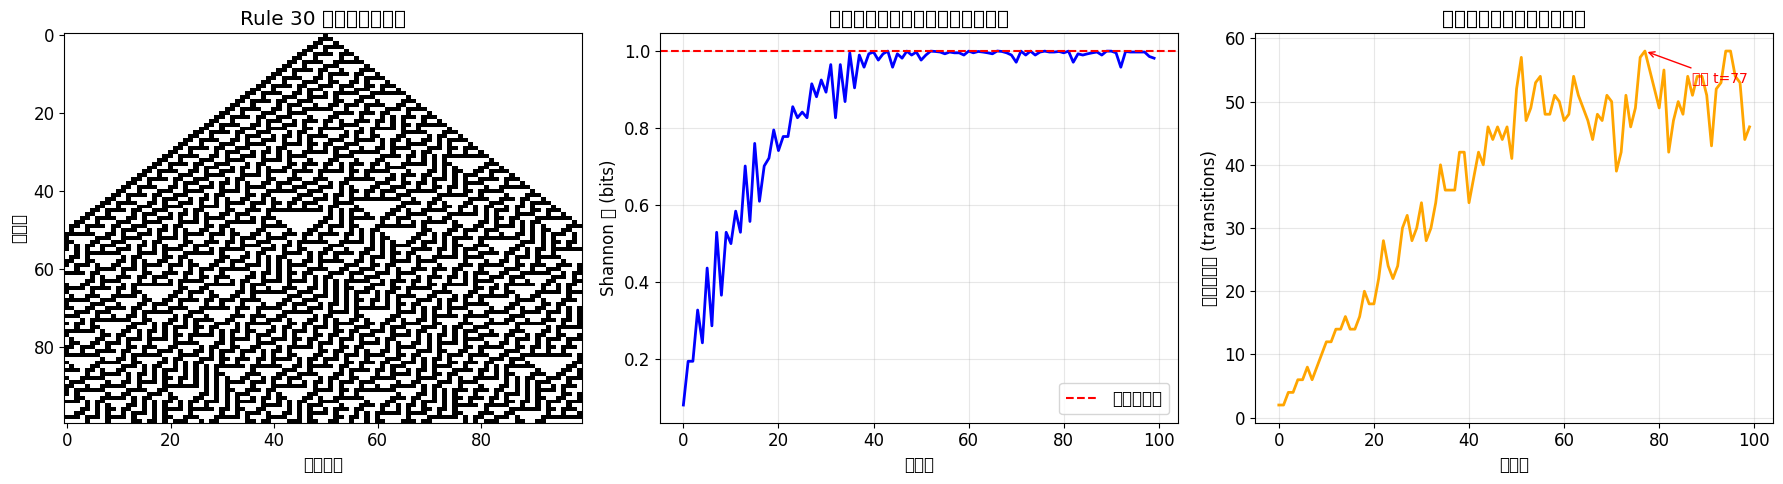


關鍵觀察：
• 熵持續增加 → 熱力學第二定律
• 複雜度先升後（趨於穩定）→ 複雜動力學第一定律


In [10]:
# 視覺化熵和複雜度變化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 左圖：細胞自動機演化
axes[0].imshow(evolution.numpy(), cmap='binary', interpolation='nearest', aspect='auto')
axes[0].set_title('Rule 30 細胞自動機演化')
axes[0].set_xlabel('細胞位置')
axes[0].set_ylabel('時間步')

# 中圖：熵變化
axes[1].plot(entropies.numpy(), linewidth=2, color='blue')
axes[1].set_xlabel('時間步')
axes[1].set_ylabel('Shannon 熵 (bits)')
axes[1].set_title('熵隨時間增加（熱力學第二定律）')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=1.0, color='red', linestyle='--', label='理論最大熵')
axes[1].legend()

# 右圖：複雜度變化
axes[2].plot(complexities.numpy(), linewidth=2, color='orange')
axes[2].set_xlabel('時間步')
axes[2].set_ylabel('空間複雜度 (transitions)')
axes[2].set_title('複雜度在中間時刻達到峰值')
axes[2].grid(True, alpha=0.3)

# 標註峰值
peak_t = complexities.argmax().item()
peak_val = complexities.max().item()
axes[2].annotate(f'峰值 t={peak_t}', xy=(peak_t, peak_val), 
                 xytext=(peak_t+10, peak_val-5),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

plt.tight_layout()
plt.show()

print("\n關鍵觀察：")
print("• 熵持續增加 → 熱力學第二定律")
print("• 複雜度先升後（趨於穩定）→ 複雜動力學第一定律")

---

## 3. 咖啡自動機：二維擴散模擬

### 3.1 擴散方程

模擬咖啡中奶油的擴散過程，使用熱傳導方程/擴散方程的離散化：

$$\frac{\partial u}{\partial t} = D \nabla^2 u$$

其中 $\nabla^2$ 是 Laplacian 算子。在離散網格上：

$$\nabla^2 u_{i,j} \approx u_{i-1,j} + u_{i+1,j} + u_{i,j-1} + u_{i,j+1} - 4u_{i,j}$$

這正好可以用卷積核 `[[0,1,0],[1,-4,1],[0,1,0]]` 實現！

In [11]:
def diffusion_2d(grid: torch.Tensor,
                 steps: int,
                 diffusion_rate: float = 0.1) -> torch.Tensor:
    """
    二維擴散模擬（咖啡中的奶油混合）
    
    使用卷積實現 Laplacian 算子，模擬擴散方程。
    
    Args:
        grid: 初始網格 (H x W tensor)
        steps: 模擬步數
        diffusion_rate: 擴散率
    
    Returns:
        演化歷史 (steps+1 x H x W tensor)
    """
    # Laplacian 卷積核
    # 計算「中心點與四個鄰居的差異」
    kernel = torch.tensor([
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0]
    ], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    
    history = [grid.clone()]
    current = grid.clone().unsqueeze(0).unsqueeze(0)  # 添加 batch 和 channel 維度
    
    for _ in range(steps):
        # 填充邊界（複製邊緣值）
        padded = F.pad(current, (1, 1, 1, 1), mode='replicate')
        
        # 卷積計算 Laplacian
        laplacian = F.conv2d(padded, kernel)
        
        # 顯式歐拉法更新
        current = current + diffusion_rate * laplacian
        current = torch.clamp(current, 0, 1)  # 保持在 [0, 1] 範圍
        
        history.append(current.squeeze().clone())
    
    return torch.stack(history)


# 展示 Laplacian 卷積核
print("Laplacian 卷積核：")
print("     [0,  1, 0]")
print("     [1, -4, 1]")
print("     [0,  1, 0]")
print("\n這個核計算中心點與四個鄰居的加權差異，實現擴散效果。")

Laplacian 卷積核：
     [0,  1, 0]
     [1, -4, 1]
     [0,  1, 0]

這個核計算中心點與四個鄰居的加權差異，實現擴散效果。


In [12]:
# 建立初始狀態：集中的「奶油」在咖啡中央
grid_size = 50
coffee = torch.zeros((grid_size, grid_size))
coffee[20:30, 20:30] = 1.0  # 奶油集中在中央 10x10 區域

print(f"☕ 咖啡杯大小: {grid_size} x {grid_size}")
print(f"🥛 奶油初始位置: [20:30, 20:30] (10x10 區域)")

# 模擬混合過程
mixing_steps = 50
mixing_history = diffusion_2d(coffee, steps=mixing_steps, diffusion_rate=0.2)

print(f"\n模擬完成: {mixing_steps} 步")
print(f"初始奶油濃度範圍: [{coffee.min():.2f}, {coffee.max():.2f}]")
print(f"最終奶油濃度範圍: [{mixing_history[-1].min():.4f}, {mixing_history[-1].max():.4f}]")

☕ 咖啡杯大小: 50 x 50
🥛 奶油初始位置: [20:30, 20:30] (10x10 區域)

模擬完成: 50 步
初始奶油濃度範圍: [0.00, 1.00]
最終奶油濃度範圍: [0.0000, 0.5378]


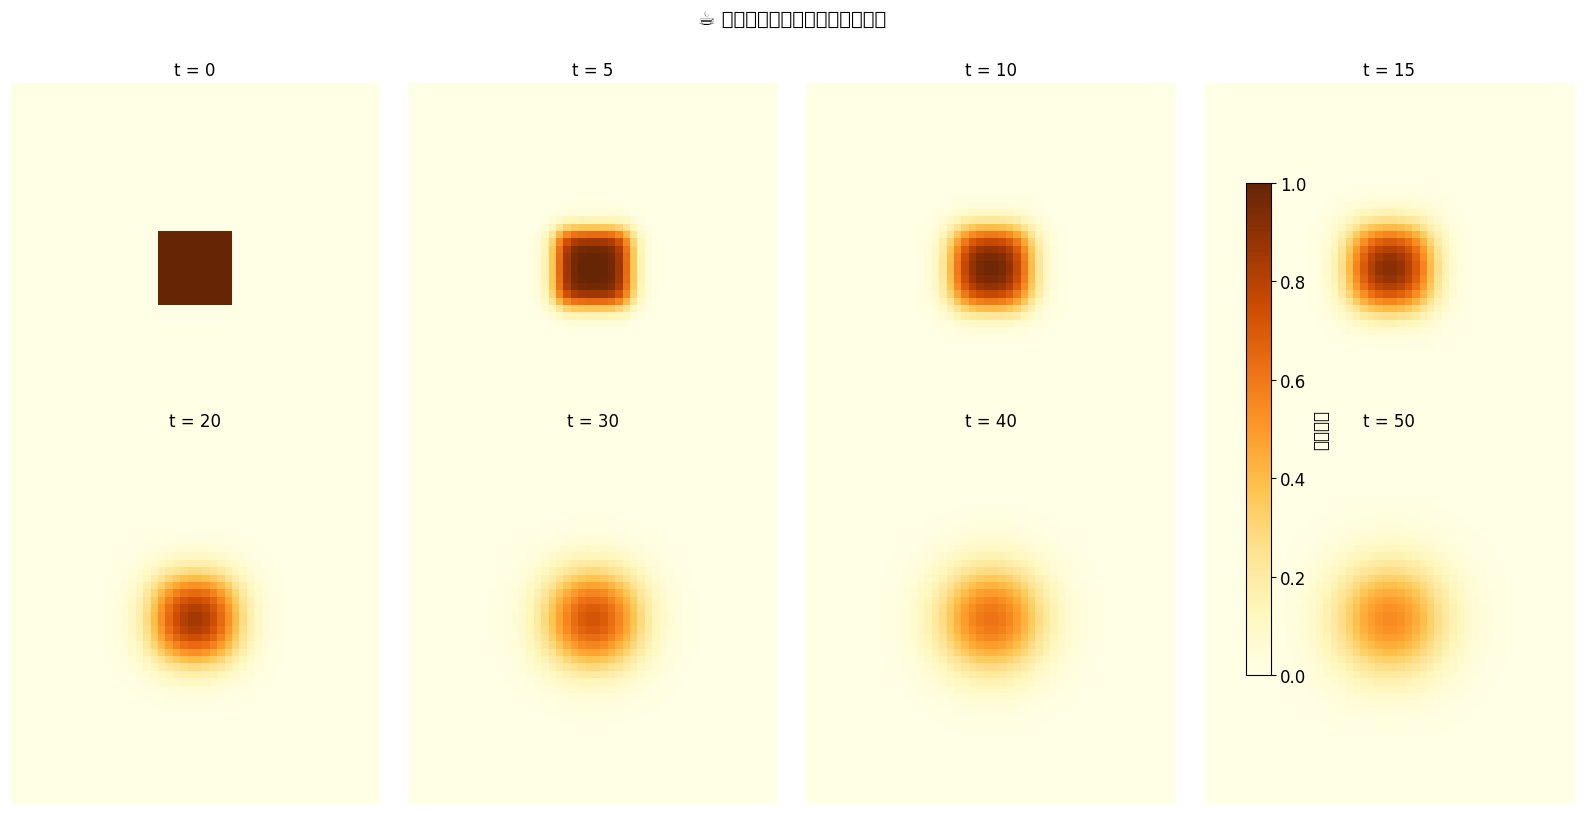

觀察：
• t=0: 奶油集中在中央（簡單、低熵）
• t=10-20: 出現複雜的擴散邊緣（複雜度峰值）
• t=50: 趨向均勻分佈（簡單、高熵）

這個過程是不可逆的——你無法『反混合』咖啡！


In [13]:
# 視覺化混合過程
timesteps = [0, 5, 10, 15, 20, 30, 40, 50]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, t in enumerate(timesteps):
    ax = axes[idx // 4, idx % 4]
    im = ax.imshow(mixing_history[t].numpy(), cmap='YlOrBr', vmin=0, vmax=1)
    ax.set_title(f't = {t}', fontsize=12)
    ax.axis('off')

# 添加顏色條
fig.colorbar(im, ax=axes, label='奶油濃度', shrink=0.8)
fig.suptitle('☕ 咖啡自動機：不可逆的混合過程', fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

print("觀察：")
print("• t=0: 奶油集中在中央（簡單、低熵）")
print("• t=10-20: 出現複雜的擴散邊緣（複雜度峰值）")
print("• t=50: 趨向均勻分佈（簡單、高熵）")
print("\n這個過程是不可逆的——你無法『反混合』咖啡！")

### 3.2 測量混合過程中的熵變化

In [14]:
def measure_spatial_entropy(grid: torch.Tensor, bins: int = 20) -> float:
    """
    計算二維網格的空間熵
    
    將連續值離散化成 bins 個區間，然後計算 Shannon 熵。
    
    Args:
        grid: 2D tensor
        bins: 直方圖的 bin 數量
    
    Returns:
        空間熵值
    """
    flat = grid.flatten()
    hist = torch.histc(flat, bins=bins, min=0, max=1)
    probs = hist / hist.sum()
    probs = probs[probs > 0]  # 移除零機率
    entropy = -torch.sum(probs * torch.log2(probs))
    return entropy.item()


# 計算混合過程中的熵變化
mixing_entropies = []
for t in range(len(mixing_history)):
    mixing_entropies.append(measure_spatial_entropy(mixing_history[t]))
mixing_entropies = torch.tensor(mixing_entropies)

print("混合過程熵變化：")
print(f"初始空間熵: {mixing_entropies[0]:.4f} bits")
print(f"最終空間熵: {mixing_entropies[-1]:.4f} bits")
print(f"熵增加:     {mixing_entropies[-1] - mixing_entropies[0]:.4f} bits")

混合過程熵變化：
初始空間熵: 0.2423 bits
最終空間熵: 1.1889 bits
熵增加:     0.9466 bits


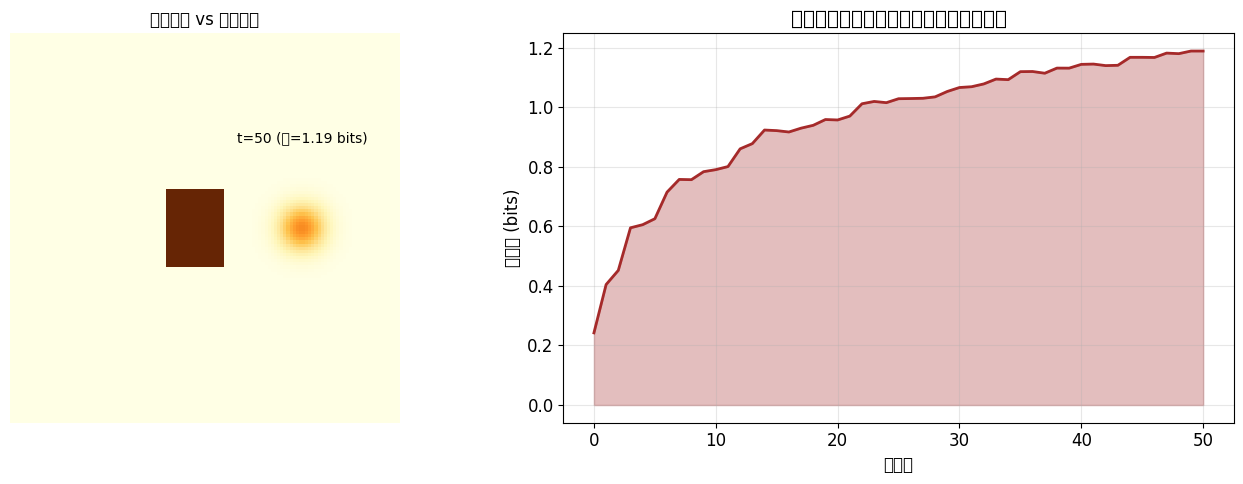

In [15]:
# 視覺化熵變化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左圖：初始 vs 最終狀態
ax1_left = axes[0]
im1 = ax1_left.imshow(mixing_history[0].numpy(), cmap='YlOrBr', vmin=0, vmax=1)
ax1_left.set_title(f't=0 (熵={mixing_entropies[0]:.2f} bits)')
ax1_left.axis('off')

# 在同一個 subplot 中創建 inset
ax1_right = axes[0].inset_axes([0.55, 0.1, 0.4, 0.8])
im2 = ax1_right.imshow(mixing_history[-1].numpy(), cmap='YlOrBr', vmin=0, vmax=1)
ax1_right.set_title(f't={mixing_steps} (熵={mixing_entropies[-1]:.2f} bits)', fontsize=10)
ax1_right.axis('off')

axes[0].set_title('初始狀態 vs 最終狀態', fontsize=12)

# 右圖：熵隨時間變化
axes[1].plot(mixing_entropies.numpy(), linewidth=2, color='brown')
axes[1].set_xlabel('時間步')
axes[1].set_ylabel('空間熵 (bits)')
axes[1].set_title('熵在混合過程中增加（熱力學第二定律）')
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(range(len(mixing_entropies)), mixing_entropies.numpy(), 
                     alpha=0.3, color='brown')

plt.tight_layout()
plt.show()

---

## 4. 複雜動力學第一定律：總結

### 4.1 對比熵與複雜度

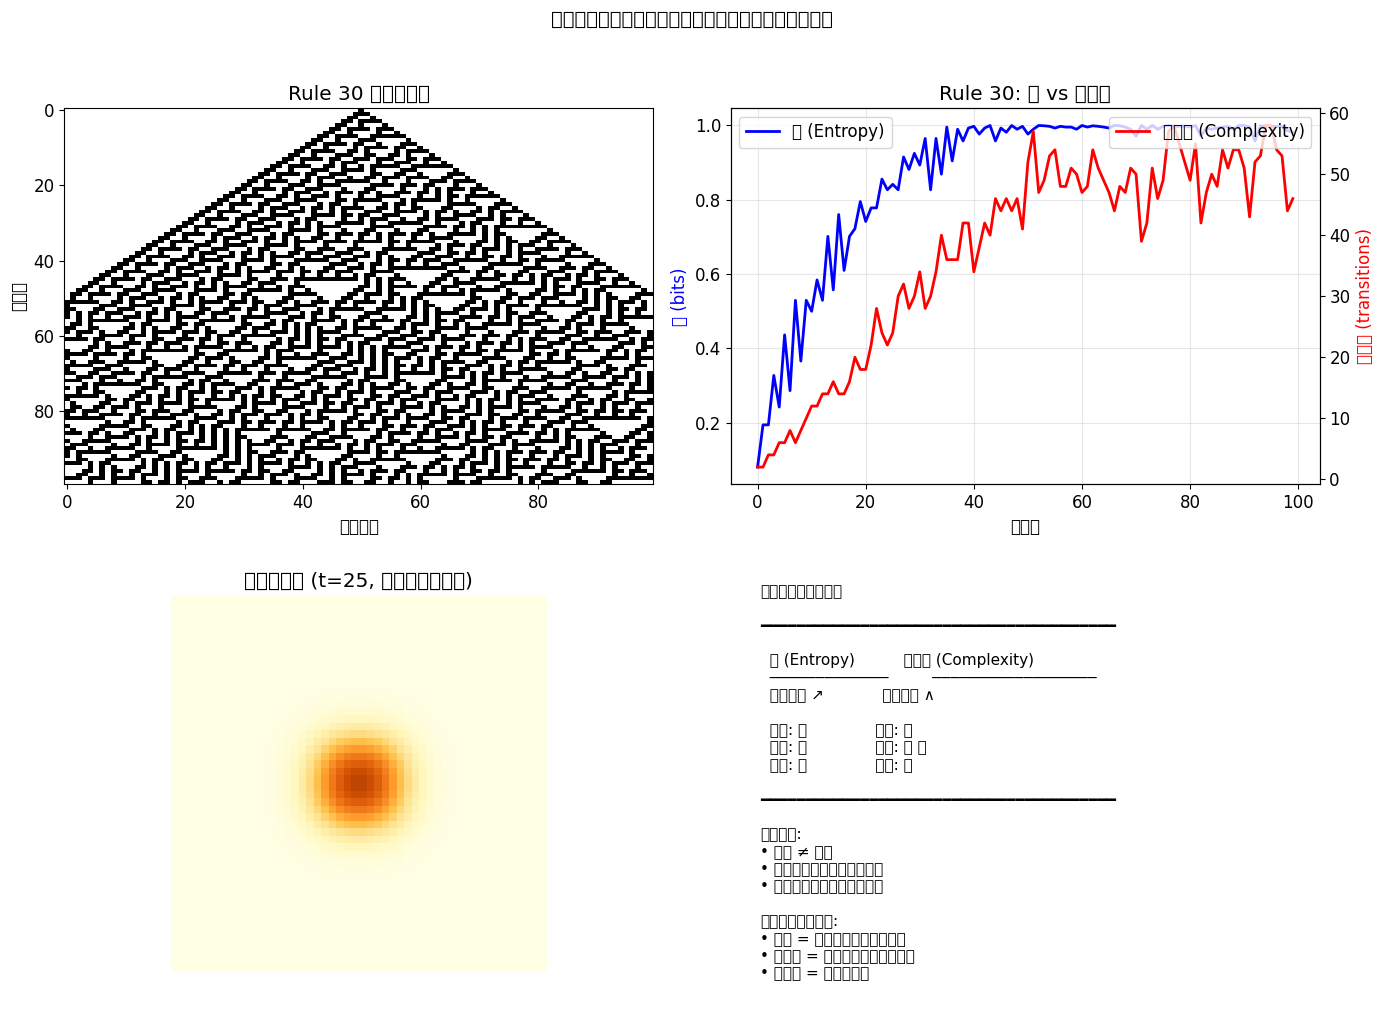

In [16]:
# 創建總結圖表
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Rule 30 演化
axes[0, 0].imshow(evolution.numpy(), cmap='binary', interpolation='nearest', aspect='auto')
axes[0, 0].set_title('Rule 30 細胞自動機')
axes[0, 0].set_xlabel('細胞位置')
axes[0, 0].set_ylabel('時間步')

# 2. Rule 30 熵 vs 複雜度
ax2 = axes[0, 1]
ax2.plot(entropies.numpy(), 'b-', linewidth=2, label='熵 (Entropy)')
ax2_twin = ax2.twinx()
ax2_twin.plot(complexities.numpy(), 'r-', linewidth=2, label='複雜度 (Complexity)')
ax2.set_xlabel('時間步')
ax2.set_ylabel('熵 (bits)', color='blue')
ax2_twin.set_ylabel('複雜度 (transitions)', color='red')
ax2.set_title('Rule 30: 熵 vs 複雜度')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# 3. 咖啡混合
axes[1, 0].imshow(mixing_history[25].numpy(), cmap='YlOrBr', vmin=0, vmax=1)
axes[1, 0].set_title('咖啡自動機 (t=25, 複雜度峰值附近)')
axes[1, 0].axis('off')

# 4. 核心概念圖
axes[1, 1].axis('off')
summary_text = """
複雜動力學第一定律

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  熵 (Entropy)          複雜度 (Complexity)
  ─────────────         ──────────────────
  永遠增加 ↗            先升後降 ∧

  初始: 低              初始: 低
  中間: 中              中間: 高 ⭐
  最終: 高              最終: 低

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

關鍵洞見:
• 隨機 ≠ 複雜
• 複雜性在中間時刻達到峰值
• 簡單規則可以產生複雜行為

與深度學習的關聯:
• 學習 = 發現有意義的複雜結構
• 過擬合 = 學到錯誤類型的複雜度
• 正規化 = 控制複雜度
"""
axes[1, 1].text(0.05, 0.5, summary_text, fontsize=11,
                verticalalignment='center', transform=axes[1, 1].transAxes)

plt.suptitle('複雜動力學第一定律：熵永遠增加，但複雜度先升後降', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 與深度學習的關聯

| 訓練階段 | 權重狀態 | 咖啡類比 |
|----------|----------|----------|
| 初始化 | 隨機小值 | 奶油剛倒入 |
| 早期訓練 | 快速變化 | 漩渦形成 |
| 中期訓練 | 複雜特徵表示 | 最美麗的漩渦 ⭐ |
| 過擬合 | 記住雜訊 | 無結構的複雜 |
| 收斂 | 穩定表示 | 混合完成 |

**啟示：**
1. **Early Stopping**：在複雜度峰值處停止訓練
2. **正規化**：控制模型複雜度，避免學到無意義的複雜性
3. **資訊瓶頸**：好的表示應該壓縮無關資訊，保留有意義的結構

---

## 5. 思考題

1. **為什麼隨機字串有最高的 Kolmogorov 複雜度，但我們不覺得它「複雜」？**

2. **如果我們能設計一個「複雜度正規化」，讓神經網路保持在複雜度峰值附近，會發生什麼？**

3. **Rule 30 從單一細胞產生複雜模式，這與神經網路從隨機初始化學習有什麼相似之處？**

4. **咖啡中的奶油最終會完全混合，但神經網路訓練不應該「完全混合」。Early Stopping 如何幫助維持適當的複雜度？**

---

## 參考資料

**論文連結：**
- 原文：https://scottaaronson.blog/?p=762
- 作者：Scott Aaronson（MIT → UT Austin 量子計算專家）

**延伸閱讀：**
- Wolfram, S. (2002). *A New Kind of Science*
- Li, M., & Vitányi, P. (2008). *An Introduction to Kolmogorov Complexity*
- Tishby, N., & Zaslavsky, N. (2015). *Deep Learning and the Information Bottleneck Principle*

---

*下一章：The Unreasonable Effectiveness of Recurrent Neural Networks*